# **Klasifikasi Negara | K-Means++**

---

Model klasifikasi negara pada kelompok tertentu berdasarkan karaktersitik menggunakan algoritma K-Means Clustering++.

**Tujuan** : 
Mengelompokkan negara-negara dalam 3 kategori(Kaya, Menengah, Miskin).

**Dikerjakan oleh:**
- Akyar Bima Arrizkillah
- Silmy Muthi'ah Aulya

**SMK Negeri 2 Singosari**

## 1. Data Preparation

### 1.1 Import Library

In [260]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-muted')
sns.set_style('whitegrid')
sns.set_context('notebook')

### 1.2 Read Dataset

In [261]:
# Membaca data dari file CSV
try:
    df = pd.read_csv('Country-data.csv')
    print('Dataset berhasil terbaca.')
except ValueError:
    print('Dataset gagal terbaca.')

Dataset berhasil terbaca.


In [262]:
# 5 baris teratas
print('5 baris teratas:')
df.head()

5 baris teratas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [263]:
# 10 baris acak
print('10 baris acak:')
df.sample(10)

10 baris acak:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
41,Croatia,5.5,37.6,7.76,38.1,20100,0.821,76.3,1.55,13500
35,Colombia,18.6,15.9,7.59,17.8,10900,3.860,76.4,2.01,6250
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
58,Germany,4.2,42.3,11.60,37.1,40400,0.758,80.1,1.39,41800
80,Kenya,62.2,20.7,4.75,33.6,2480,2.090,62.8,4.37,967
135,Slovenia,3.2,64.3,9.41,62.9,28700,-0.987,79.5,1.57,23400
132,Sierra Leone,160.0,16.8,13.10,34.5,1220,17.200,55.0,5.20,399
42,Cyprus,3.6,50.2,5.97,57.5,33900,2.010,79.9,1.42,30800
136,Solomon Islands,28.1,49.3,8.55,81.2,1780,6.810,61.7,4.24,1290
144,Sweden,3.0,46.2,9.63,40.7,42900,0.991,81.5,1.98,52100


In [264]:
# Dimensi data
print('Jumlah baris:',df.shape[0])
print('Jumlah kolom:',df.shape[1])

Jumlah baris: 167
Jumlah kolom: 10


In [265]:
# Ringkasan informasi
print('Ringkasan informasi:')
df.info()

Ringkasan informasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


**Data Dictionary**

| Nama Fitur | Deskripsi |
| :--- | :--- |
| **country** | Nama negara |
| **child_mort** | Jumlah kematian anak usia di bawah 5 tahun per 1.000 kelahiran hidup |
| **exports** | Persentase nilai ekspor terhadap Produk Domestik Bruto (GDP) |
| **health** | Persentase pengeluaran kesehatan terhadap GDP |
| **imports** | Persentase nilai impor terhadap Produk Domestik Bruto (GDP) |
| **income** | Pendapatan rata-rata per kapita penduduk |
| **inflation** | Tingkat inflasi tahunan suatu negara (dalam persen) |
| **life_expec** | Angka harapan hidup penduduk (dalam tahun) |
| **total_fer** | *Total fertility rate*, yaitu rata-rata jumlah anak yang dilahirkan oleh seorang wanita |
| **gdpp** | Produk Domestik Bruto per kapita (*GDP per capita*) |

In [266]:
# Ringkasan statistik
print('Ringkasan statistik:')
df.describe()

Ringkasan statistik:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [267]:
# Jumlah nilai unik perkolom
print('Jumlah nilai unik perkolom:\n')
for col in df.columns:
    print(col, ':', df[col].nunique())

Jumlah nilai unik perkolom:

country : 167
child_mort : 139
exports : 147
health : 147
imports : 151
income : 156
inflation : 156
life_expec : 127
total_fer : 138
gdpp : 157


In [268]:
# Simpan kolom pada variabel sesuai jenis tipe data
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

In [269]:
# Nilai unik pada fitur 'country'
print('Cek nilai unik pada kolom kategori: ')
for col in categorical_columns:
    print(col, df[col].unique())


Cek nilai unik pada kolom kategori: 
country ['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark' 'Dominican Republic'
 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kiribati'
 'Kuwait' 'Kyrgyz Republic' 'L

### 1.3 Missing Value

In [270]:
# Cek Missing Value
print('Total nilai kosong:', df.isnull().sum().sum())

Total nilai kosong: 0


### 1.4 Nilai Duplikat


In [271]:
print('Jumlah nilai duplikat:',df.duplicated().sum())

Jumlah nilai duplikat: 0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Outlier

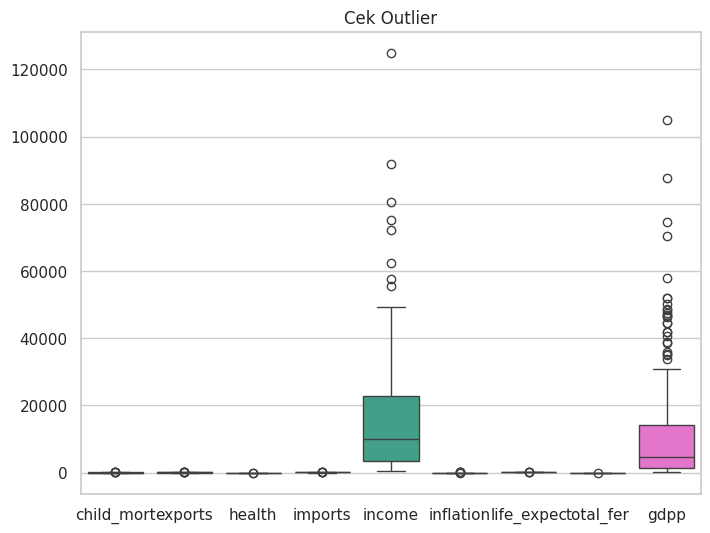

In [272]:
# Cek outlier pada fitur numerik menggunakan boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df)
plt.title(f'Cek Outlier')
plt.show()


In [273]:
# Cek outlier dengan teknik IQR 
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.log1p(df[col])


/home/akyrr/Documents/Akyr/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


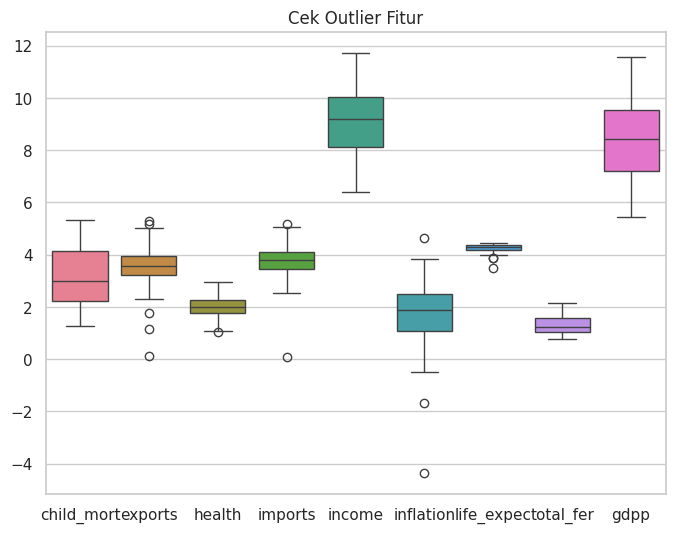

In [274]:
plt.figure(figsize=(8,6))
sns.boxplot(df)
plt.title(f'Cek Outlier Fitur')
plt.show()

### 2.2 Negara dengan Income Tertinggi dan Terendah

In [275]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,4.513055,2.397895,2.149434,3.826465,7.384610,2.345645,4.046554,1.919859,6.317165
1,Albania,2.867899,3.367296,2.021548,3.903991,9.203416,1.702928,4.347694,0.974560,8.316545
2,Algeria,3.342862,3.673766,1.642873,3.478158,9.465060,2.839078,4.350278,1.358409,8.403128
3,Angola,4.787492,4.147885,1.348073,3.781914,8.682877,3.152736,4.112512,1.968510,8.169336
4,Antigua and Barbuda,2.424803,3.839452,1.950187,4.092677,9.857496,0.891998,4.354141,1.141033,9.409273


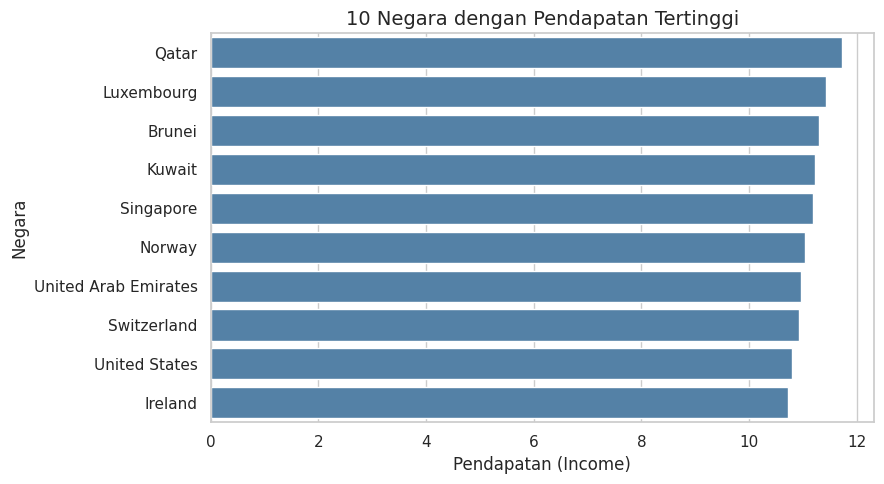

In [276]:
# 10 negara dengan income tertinggi
top_10_income = df.nlargest(10, 'income')

plt.figure(figsize=(9, 5))
sns.set_style('whitegrid')

sns.barplot(
    data=top_10_income, 
    x='income', 
    y='country', 
    color='steelblue'
)

plt.title('10 Negara dengan Pendapatan Tertinggi', fontsize=14)
plt.xlabel('Pendapatan (Income)')
plt.ylabel('Negara')

plt.tight_layout()
plt.show()

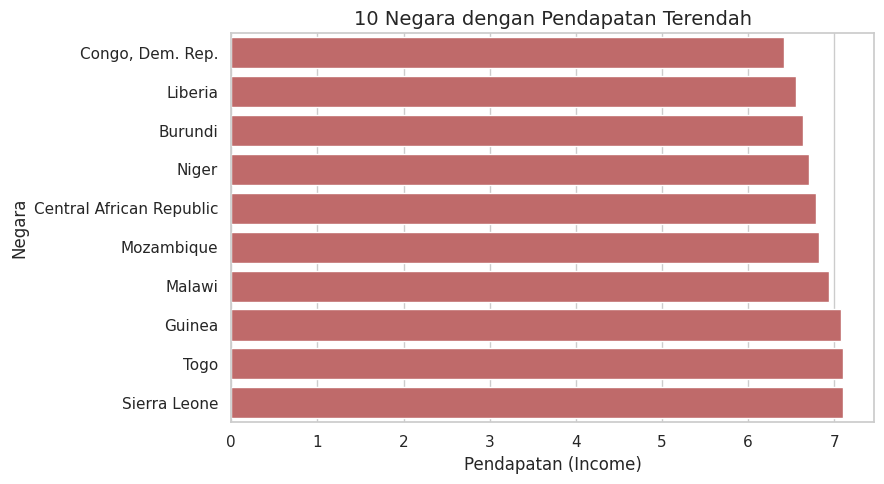

In [277]:
#  10 negara dengan income terendah
bottom_10_income = df.nsmallest(10, 'income')
plt.figure(figsize=(9, 5))
sns.set_style('whitegrid')
sns.barplot(
    data=bottom_10_income, 
    x='income', 
    y='country', 
    color='indianred'
)
plt.title('10 Negara dengan Pendapatan Terendah', fontsize=14)
plt.xlabel('Pendapatan (Income)')
plt.ylabel('Negara')
plt.tight_layout()
plt.show()

## 3. Model 

In [278]:
# Log Transformation 
df_log = np.log1p(df[numerical_columns])

# Normalisasi
df_min = df_log.min()
df_max = df_log.max()
data_scaled = (df_log - df_min) / (df_max - df_min)

X = data_scaled.values  

/home/akyrr/Documents/Akyr/venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [279]:
def k_means_plus_plus_engine(data, k, max_iter=500):
    data = np.nan_to_num(data.astype(float)) # Ubah NaN jadi 0 dan Inf jadi angka besar
    n_samples = data.shape[0]
    
    # Inisialisasi centroid awal
    centroids = [data[np.random.randint(n_samples)]] # Pilih satu centroid secara acak 
    for _ in range(1, k):
        # Jarak Encludian
        dist_sq = np.array([min([np.sum((x - c)**2) for c in centroids]) for x in data])
        
        # Mencegah pembagian dengan nol jika semua jarak adalah 0
        sum_dist = dist_sq.sum()
        if sum_dist == 0:
            probs = np.ones(n_samples) / n_samples
        else:
            probs = dist_sq / sum_dist
        
        # membuat probs menjadi 1
        probs = probs / probs.sum()
        
        idx = np.random.choice(n_samples, p=probs)
        centroids.append(data[idx])
    
    centroids = np.array(centroids)
    
    # Iterasi
    for _ in range(max_iter):
        distances = np.sqrt(((data[:, np.newaxis] - centroids)**2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        
        new_centroids = np.array([data[labels == j].mean(axis=0) if len(data[labels == j]) > 0 
                                  else centroids[j] for j in range(k)])
        
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
        
    # Hitung SSE
    sse = 0
    for j in range(k):
        if len(data[labels == j]) > 0:
            sse += np.sum((data[labels == j] - centroids[j])**2)
            
    return labels, centroids, sse

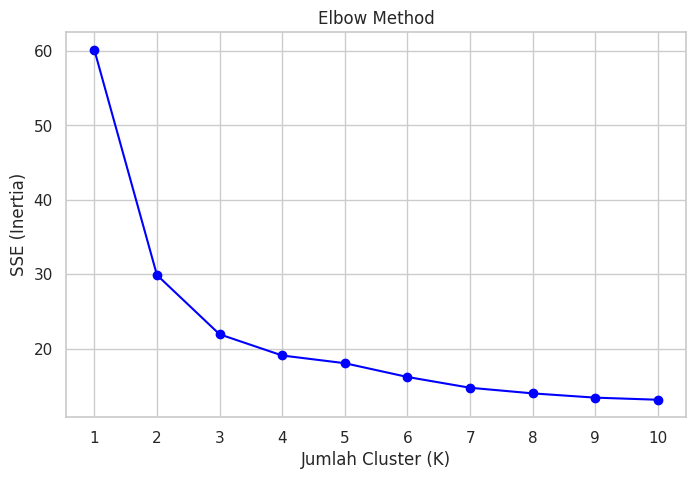

In [280]:
sse_list = []
k_range = range(1, 11)

for k in k_range:
    # Menggunakan fungsi engine yang sudah diperbaiki sebelumnya
    _, _, sse = k_means_plus_plus_engine(X, k)
    sse_list.append(sse)

# Plotting ke Matplotlib
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse_list, marker='o',  color='b')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('SSE (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### 4. Visualisasi

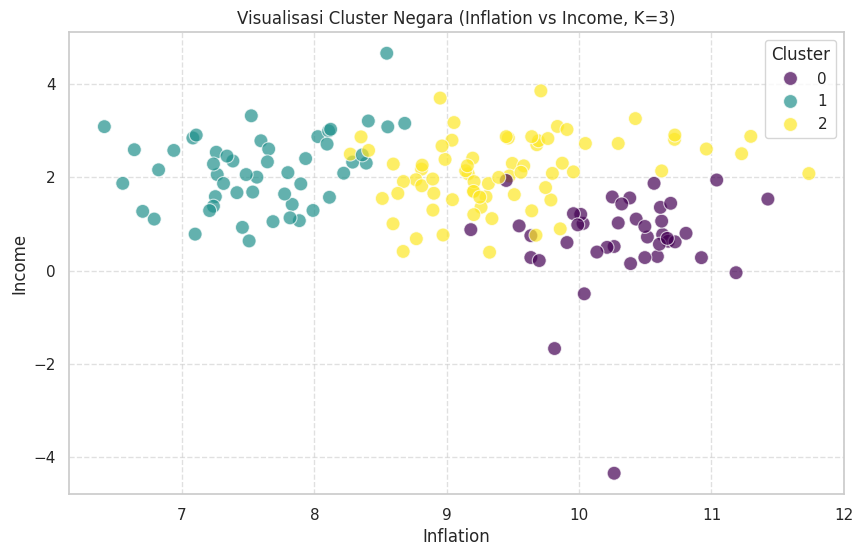

In [281]:
k_optimal = 3
labels, centroids, _ = k_means_plus_plus_engine(X, k_optimal)

# Masukkan ke dataframe asli untuk visualisasi
df['Cluster'] = labels

plt.figure(figsize=(10, 6))

# Scatter plot Inflation vs Income
sns.scatterplot(
    data=df,
    y='inflation',
    x='income',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)

plt.title(f'Visualisasi Cluster Negara (Inflation vs Income, K={k_optimal})')
plt.xlabel('Inflation')
plt.ylabel('Income')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


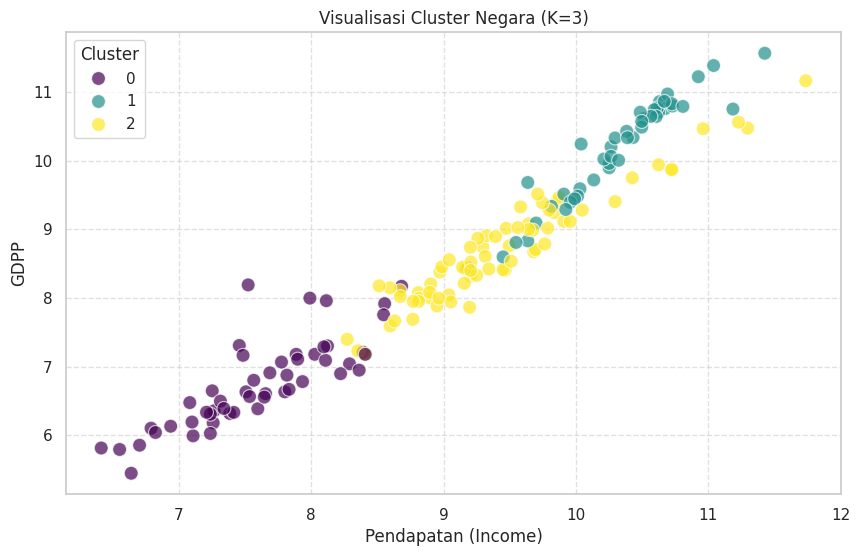

In [282]:
k_optimal = 3
labels, centroids, _ = k_means_plus_plus_engine(X, k_optimal)

# Masukkan ke dataframe asli untuk visualisasi
df['Cluster'] = labels

plt.figure(figsize=(10, 6))

# Scatter plot Income vs Child Mortality
sns.scatterplot(data=df, x='income', y='gdpp', hue='Cluster', 
                palette='viridis', s=100, alpha=0.7)

plt.title(f'Visualisasi Cluster Negara (K={k_optimal})')
plt.xlabel('Pendapatan (Income)')
plt.ylabel('GDPP')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Evaluasi 

In [283]:
def silhouette_score_manual(data, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0

    silhouette_vals = []

    for i in range(len(data)):
        same_cluster = data[labels == labels[i]]

        if len(same_cluster) <= 1:
            continue

        distances = np.linalg.norm(same_cluster - data[i], axis=1)
        a_i = np.mean(distances[distances != 0])

        b_i = np.inf
        for lbl in unique_labels:
            if lbl != labels[i]:
                cluster = data[labels == lbl]
                dist = np.mean(np.linalg.norm(cluster - data[i], axis=1))
                b_i = min(b_i, dist)

        denom = max(a_i, b_i)
        if denom > 0:
            silhouette_vals.append((b_i - a_i) / denom)

    if len(silhouette_vals) == 0:
        return 0

    return np.mean(silhouette_vals)



/tmp/ipykernel_6018/4070907273.py:26: RuntimeWarning: invalid value encountered in scalar divide
  silhouette_vals.append((b_i - a_i) / denom)


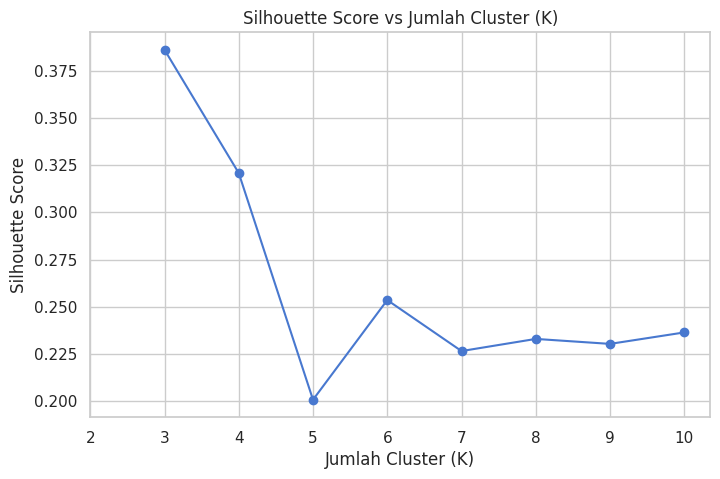

In [284]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    labels, _, _ = k_means_plus_plus_engine(X, k)
    silhouette_scores.append(silhouette_score_manual(X, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score vs Jumlah Cluster (K)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()
